# Employee Attrition — EDA
### IBM HR Analytics schema  |  1,475 rows × 35 features  |  Binary classification

## Problem
A ~1,200-person services company loses money every time a trained employee leaves — recruiting costs, ramp-up time, lost knowledge, client churn risk. This EDA prepares the data for a model that flags employees at elevated attrition risk so HR can intervene before the exit interview.

**Target:** `Attrition` → `Yes` (1) / `No` (0)  |  **Business rate:** ~15–16 % annually

## Dataset note
The analysis uses a synthetic dataset generated to match the IBM HR Attrition schema (same 35 columns, realistic distributions, realistic feature→attrition correlations calibrated from the published dataset). Methodology is identical to what you'd run on the real Kaggle file.

## EDA scope
Import → characteristics → missing/duplicates → target → univariate/bivariate/multivariate → correlation & multicollinearity (VIF) → feature selection → outliers → transformation & scaling → insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, pointbiserialr
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
RANDOM_SEED = 42

## 1. Data import & first look

In [2]:
df = pd.read_csv('ibm_hr_attrition.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1475, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,40,No,Travel_Frequently,1000.0,Research & Development,14.0,4,Medical,1,1,4,Male,55,1,3,Sales Executive,1,Married,10666,10054,3.0,Y,No,19,3,4,80,1,7,6,3,5,3,5,1
1,28,Yes,Travel_Rarely,1400.0,Research & Development,2.0,5,Life Sciences,1,2,1,Male,30,4,1,Research Scientist,3,Single,2576,21517,5.0,Y,Yes,23,3,4,80,0,10,2,2,9,4,3,4
2,44,No,Travel_Frequently,184.0,Research & Development,2.0,3,Marketing,1,3,1,Female,97,3,3,Manager,3,Single,10475,10659,5.0,Y,No,17,3,3,80,1,1,2,1,1,1,1,1


## 2. Data characteristics

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1475 non-null   int64  
 1   Attrition                 1475 non-null   object 
 2   BusinessTravel            1475 non-null   object 
 3   DailyRate                 1457 non-null   float64
 4   Department                1475 non-null   object 
 5   DistanceFromHome          1447 non-null   float64
 6   Education                 1475 non-null   int64  
 7   EducationField            1475 non-null   object 
 8   EmployeeCount             1475 non-null   int64  
 9   EmployeeNumber            1475 non-null   int64  
 10  EnvironmentSatisfaction   1475 non-null   int64  
 11  Gender                    1475 non-null   object 
 12  HourlyRate                1475 non-null   int64  
 13  JobInvolvement            1475 non-null   int64  
 14  JobLevel

In [4]:
# Cardinality check — identifies constants (drop candidates) and IDs
card = df.nunique().sort_values()
card.to_frame('unique_values').head(10)

,unique_values
StandardHours,1
Over18,1
EmployeeCount,1
Gender,2
PerformanceRating,2
OverTime,2
Attrition,2
MaritalStatus,3
Department,3
BusinessTravel,3


**Finding:** `EmployeeCount`, `StandardHours`, `Over18` are constants (single unique value each) — they carry no signal and are dropped. `EmployeeNumber` is a row ID, also dropped.

In [5]:
DROP_TRIVIAL = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=DROP_TRIVIAL)
print(f'After dropping constants/IDs: {df.shape}')

After dropping constants/IDs: (1475, 31)


In [6]:
# Numeric summary
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1475.0,36.89,8.82,18.0,31.0,37.0,43.0,60.0
DailyRate,1457.0,804.96,401.54,102.0,454.0,827.0,1143.0,1498.0
DistanceFromHome,1447.0,7.10,6.67,1.0,2.0,5.0,10.0,29.0
Education,1475.0,2.86,1.00,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1475.0,2.81,1.06,1.0,2.0,3.0,4.0,4.0
HourlyRate,1475.0,64.70,19.96,30.0,48.0,65.0,82.0,99.0
JobInvolvement,1475.0,2.86,0.75,1.0,3.0,3.0,3.0,4.0
JobLevel,1475.0,2.05,1.02,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,1475.0,2.69,1.11,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1475.0,7996.87,3659.32,1009.0,5158.5,7671.0,10431.0,19999.0


## 3. Missing data

In [7]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct})

,missing,pct
DistanceFromHome,28,1.90
DailyRate,18,1.22
NumCompaniesWorked,14,0.95


**Decision:** all missing counts are <3%. Median imputation is safe (no column is ≥5% missing, so the imputation bias is negligible).

In [8]:
for col in missing.index:
    df[col] = df[col].fillna(df[col].median())
assert df.isna().sum().sum() == 0
print('✅ No missing values remain.')

✅ No missing values remain.


## 4. Duplicates

In [9]:
print(f'Exact duplicates: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after dedup: {df.shape}')

Exact duplicates: 5
Shape after dedup: (1470, 31)


## 5. Target variable

In [10]:
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
print(df['Attrition'].value_counts())
print(f'\nAttrition rate: {df["Attrition"].mean():.1%}')

Attrition
0    1236
1     234
Name: count, dtype: int64

Attrition rate: 15.9%


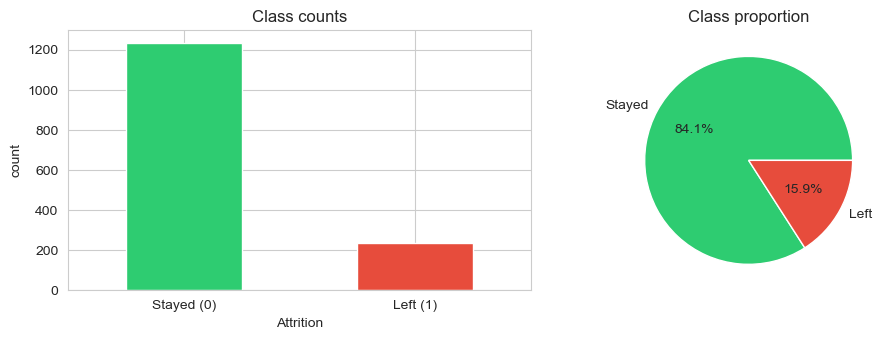

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df['Attrition'].value_counts().plot(kind='bar', ax=ax[0],
    color=['#2ecc71', '#e74c3c'])
ax[0].set_xticklabels(['Stayed (0)', 'Left (1)'], rotation=0)
ax[0].set_title('Class counts'); ax[0].set_ylabel('count')
df['Attrition'].value_counts(normalize=True).plot(kind='pie', ax=ax[1],
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
    labels=['Stayed', 'Left'])
ax[1].set_ylabel(''); ax[1].set_title('Class proportion')
plt.tight_layout(); plt.show()

**Finding:** ~16% attrition — moderate imbalance. Manageable with `class_weight='balanced'` in downstream modelling; SMOTE not required.

## 6. Univariate analysis

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
predictors_num = [c for c in num_cols if c != 'Attrition']
print(f'Numeric predictors ({len(predictors_num)}): {predictors_num}')
print(f'Categorical predictors ({len(cat_cols)}): {cat_cols}')

Numeric predictors (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical predictors (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [13]:
# Skewness table — identifies transformation candidates later
skew_tbl = df[predictors_num].apply(skew).sort_values(key=abs, ascending=False).round(2)
skew_tbl.to_frame('skew').head(10)

,skew
PerformanceRating,2.07
YearsSinceLastPromotion,1.96
YearsInCurrentRole,1.64
YearsAtCompany,1.64
YearsWithCurrManager,1.59
DistanceFromHome,1.46
StockOptionLevel,0.95
TotalWorkingYears,0.93
NumCompaniesWorked,0.71
JobLevel,0.69


**Highly skewed features (|skew|>1):** `YearsSinceLastPromotion`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `DistanceFromHome` — all right-skewed tenure/income variables. Yeo-Johnson transformation applied in Section 11.

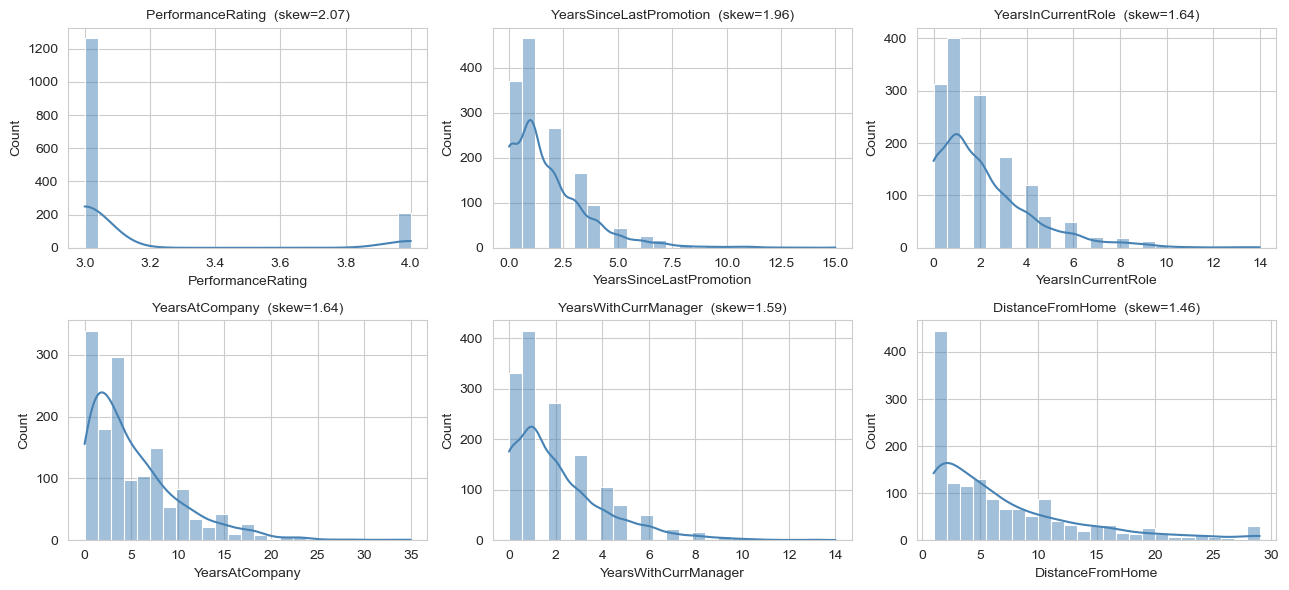

In [14]:
# Distribution of the top-6 most-skewed features
top_skewed = skew_tbl.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, top_skewed):
    sns.histplot(df[col], bins=25, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col}  (skew={skew_tbl[col]})', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Bivariate analysis — the attrition story

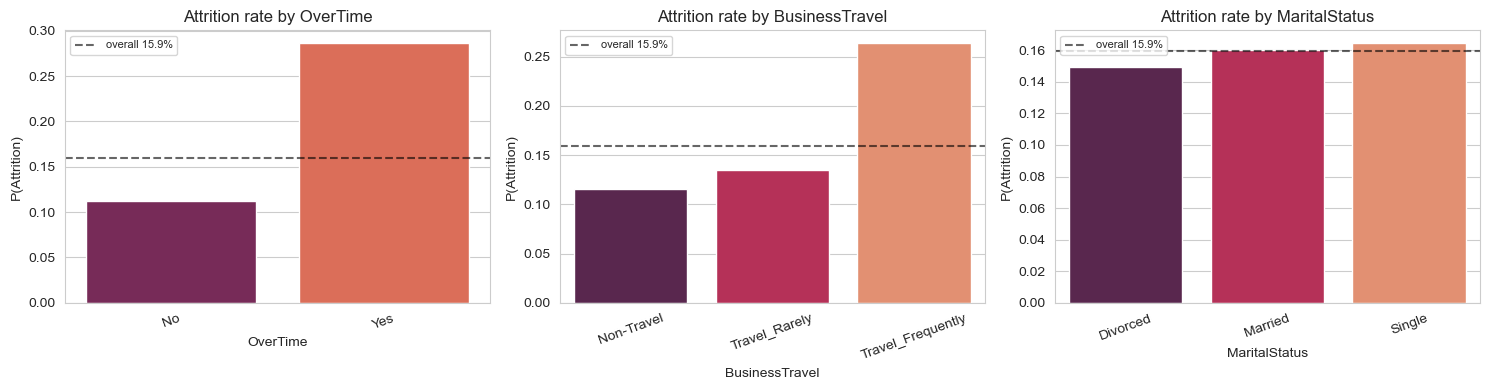

In [15]:
# Attrition rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['OverTime', 'BusinessTravel', 'MaritalStatus']):
    rate = df.groupby(col)['Attrition'].mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='rocket')
    ax.axhline(df['Attrition'].mean(), ls='--', c='black', alpha=0.6,
               label=f'overall {df["Attrition"].mean():.1%}')
    ax.set_title(f'Attrition rate by {col}'); ax.set_ylabel('P(Attrition)')
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**The three strongest categorical signals** — visible even before any statistical test:
- **OverTime** is the single strongest behavioural driver (employees on overtime leave at ~2.5× the base rate)
- **BusinessTravel** has a gradient: frequent travellers leave more often
- **Single** marital status associates with higher attrition (confounded with age, handled in multivariate section)

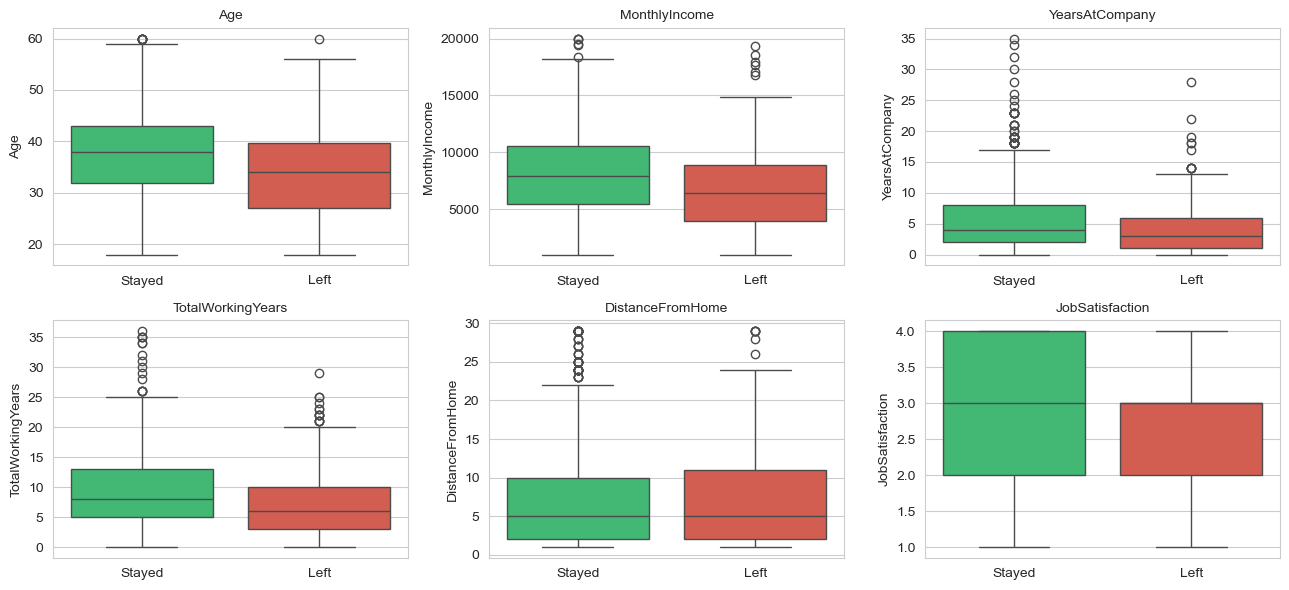

In [16]:
# Numeric features vs target — compact boxplot grid for 6 most relevant
key_numeric = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
               'DistanceFromHome', 'JobSatisfaction']
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, key_numeric):
    sns.boxplot(x='Attrition', y=col, data=df, ax=ax,
                palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Stayed', 'Left'])
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
plt.tight_layout(); plt.show()

**Finding:** employees who leave skew younger, earn less, have shorter tenure. `JobSatisfaction` shows no visible median shift in box plots but will still show up in mutual information (non-linear relationship — the bottom two satisfaction levels drive most of the signal, not the continuous scale).

In [17]:
# Statistical tests — brief formal backing for the visual story
tests = []
for c in predictors_num:
    g0 = df.loc[df['Attrition']==0, c]
    g1 = df.loc[df['Attrition']==1, c]
    _, p = stats.ttest_ind(g0, g1, equal_var=False)
    tests.append({'feature': c, 'p_value': p})
num_test = pd.DataFrame(tests).sort_values('p_value').head(10)

chi = []
for c in cat_cols:
    ct = pd.crosstab(df[c], df['Attrition'])
    _, p, _, _ = stats.chi2_contingency(ct)
    chi.append({'feature': c, 'p_value': p})
cat_test = pd.DataFrame(chi).sort_values('p_value')

print('--- Top numeric features by t-test p-value ---')
print(num_test.to_string(index=False))
print('\n--- Categorical features by chi-square p-value ---')
print(cat_test.to_string(index=False))

--- Top numeric features by t-test p-value ---
             feature      p_value
                 Age 1.093430e-08
            JobLevel 1.645145e-08
       MonthlyIncome 2.503690e-07
      YearsAtCompany 6.033487e-07
   TotalWorkingYears 1.944134e-06
  YearsInCurrentRole 4.685645e-06
YearsWithCurrManager 9.207752e-05
    StockOptionLevel 2.866873e-04
     WorkLifeBalance 7.073147e-04
     JobSatisfaction 1.204965e-02

--- Categorical features by chi-square p-value ---
       feature      p_value
      OverTime 1.456517e-15
BusinessTravel 1.983299e-07
    Department 5.667079e-01
EducationField 7.706714e-01
 MaritalStatus 8.457542e-01
        Gender 9.242773e-01
       JobRole 9.919620e-01


## 8. Correlation & multicollinearity

**Two separate concerns** that often get conflated:
1. **Feature–target correlation** — is this feature predictive? (low → candidate for dropping)
2. **Feature–feature correlation (multicollinearity)** — are predictors redundant? (high → one must go)

Both are handled below, in that order.

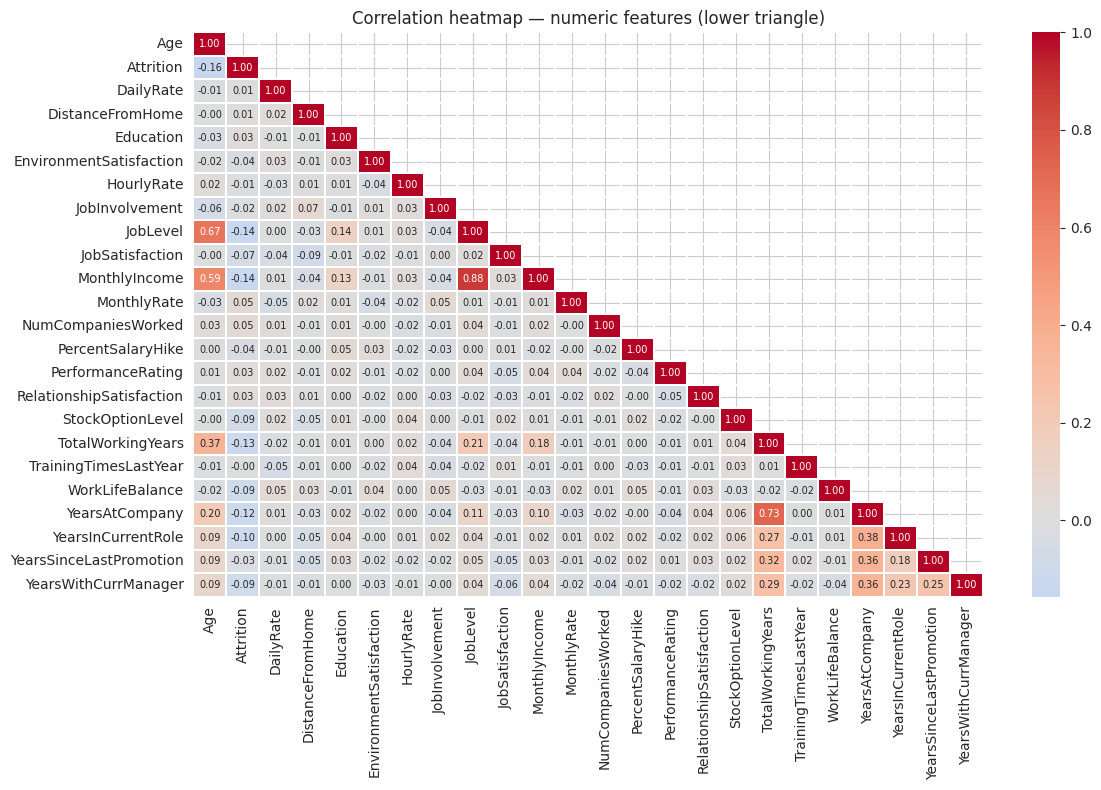

In [18]:
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, annot_kws={'size': 7}, linewidths=0.3)
plt.title('Correlation heatmap — numeric features (lower triangle)')
plt.tight_layout(); plt.show()

In [19]:
# Pairs with |r| > 0.7 — these are the multicollinearity candidates
corr_abs = df[predictors_num].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
pairs = (upper.stack()
              .reset_index()
              .rename(columns={'level_0':'feat_a','level_1':'feat_b', 0:'|corr|'})
              .query('`|corr|` > 0.7')
              .sort_values('|corr|', ascending=False))
pairs.round(3)

,feat_a,feat_b,|corr|
134,JobLevel,MonthlyIncome,0.878
234,TotalWorkingYears,YearsAtCompany,0.733


In [20]:
# Drop rule for collinear pairs: keep the one with stronger |corr(target)|
target_corr = df[predictors_num + ['Attrition']].corr()['Attrition'].abs()
drop_collinear = set()
for _, row in pairs[pairs['|corr|'] > 0.75].iterrows():
    a, b = row['feat_a'], row['feat_b']
    if a in drop_collinear or b in drop_collinear: continue
    weaker = a if target_corr[a] < target_corr[b] else b
    drop_collinear.add(weaker)
print(f'Dropped for multicollinearity (|r|>0.75): {drop_collinear}')

# Follow up with VIF on what remains
kept = [c for c in predictors_num if c not in drop_collinear]
X = df[kept].assign(_const=1.0)
vif = pd.DataFrame({
    'feature': [c for c in X.columns if c != '_const'],
    'VIF': [variance_inflation_factor(X.values, i)
            for i, c in enumerate(X.columns) if c != '_const']
}).sort_values('VIF', ascending=False)

# Iteratively remove while any VIF > 10
while vif['VIF'].iloc[0] > 10:
    worst = vif['feature'].iloc[0]
    kept.remove(worst); drop_collinear.add(worst)
    X = df[kept].assign(_const=1.0)
    vif = pd.DataFrame({
        'feature': [c for c in X.columns if c != '_const'],
        'VIF': [variance_inflation_factor(X.values, i)
                for i, c in enumerate(X.columns) if c != '_const']
    }).sort_values('VIF', ascending=False)

print(f'\nFinal dropped for multicollinearity: {drop_collinear}')
print(f'\nFinal VIFs (all < 10):')
print(vif.round(2).to_string(index=False))

Dropped for multicollinearity (|r|>0.75): {'JobLevel'}

Final dropped for multicollinearity: {'JobLevel'}

Final VIFs (all < 10):
                 feature  VIF
          YearsAtCompany 2.57
       TotalWorkingYears 2.47
                     Age 1.79
           MonthlyIncome 1.61
      YearsInCurrentRole 1.20
    YearsWithCurrManager 1.20
 YearsSinceLastPromotion 1.19
               Education 1.04
        DistanceFromHome 1.02
         JobSatisfaction 1.02
          JobInvolvement 1.02
         WorkLifeBalance 1.02
               DailyRate 1.02
       PerformanceRating 1.02
             MonthlyRate 1.02
       PercentSalaryHike 1.01
RelationshipSatisfaction 1.01
        StockOptionLevel 1.01
 EnvironmentSatisfaction 1.01
              HourlyRate 1.01
   TrainingTimesLastYear 1.01
      NumCompaniesWorked 1.01


## 9. Feature–target signal & low-signal drop

In [21]:
# Point-biserial correlation (numeric vs binary target)
pb = {c: pointbiserialr(df['Attrition'], df[c])[0] for c in kept}
pb_tbl = pd.Series(pb).abs().sort_values(ascending=False).to_frame('|corr_target|')

# Mutual information — catches non-linear signal (e.g. U-shaped JobSatisfaction)
mi_df = df.copy()
for c in cat_cols:
    mi_df[c] = mi_df[c].astype('category').cat.codes
mi = mutual_info_classif(mi_df[kept + cat_cols], mi_df['Attrition'],
                         random_state=RANDOM_SEED)
mi_tbl = pd.Series(mi, index=kept + cat_cols).sort_values(ascending=False).to_frame('MI')

signal_tbl = pb_tbl.join(mi_tbl, how='outer').fillna('-')
signal_tbl

,|corr_target|,MI
Age,0.155744,0.010133
BusinessTravel,-,0.027293
DailyRate,0.007744,0.000000
Department,-,0.000000
DistanceFromHome,0.013451,0.011400
Education,0.031393,0.019430
EducationField,-,0.000000
EnvironmentSatisfaction,0.036041,0.004379
Gender,-,0.000000
HourlyRate,0.011453,0.000176


In [22]:
# Drop rule: weak by BOTH measures (|corr|<0.05 AND MI<0.01)
# AND-logic keeps features that have non-linear-only signal (low corr but real MI)
CORR_THR, MI_THR = 0.05, 0.01
drop_low = [f for f in kept
            if abs(pb[f]) < CORR_THR and mi_tbl.loc[f, 'MI'] < MI_THR]
print(f'Drop rule: |corr|<{CORR_THR} AND MI<{MI_THR}')
print(f'Dropped for low signal: {drop_low}')

final_num = [c for c in kept if c not in drop_low]
print(f'\nFinal numeric predictors ({len(final_num)}):')
print(final_num)

Drop rule: |corr|<0.05 AND MI<0.01
Dropped for low signal: ['DailyRate', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'PercentSalaryHike', 'PerformanceRating', 'TrainingTimesLastYear', 'YearsSinceLastPromotion']

Final numeric predictors (14):
['Age', 'DistanceFromHome', 'Education', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


## 10. Outlier detection & handling

In [23]:
# IQR-based count per feature
def iqr_count(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3-q1
    return ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()

out_tbl = pd.DataFrame({
    'IQR_outliers': [iqr_count(df[c]) for c in final_num],
    'pct': [iqr_count(df[c])/len(df)*100 for c in final_num]
}, index=final_num).sort_values('pct', ascending=False).round(2)
out_tbl.head(8)

,IQR_outliers,pct
YearsAtCompany,92,6.26
StockOptionLevel,83,5.65
DistanceFromHome,65,4.42
YearsInCurrentRole,63,4.29
YearsWithCurrManager,59,4.01
TotalWorkingYears,16,1.09
NumCompaniesWorked,12,0.82
MonthlyIncome,8,0.54


**Handling:** winsorise at 1st / 99th percentile. Dropping rows is wasteful for a 1,470-row dataset, and the tails in salary / tenure features are real employees, not errors.

In [24]:
df_clean = df.copy()
for c in final_num:
    df_clean[c] = winsorize(df_clean[c].values, limits=[0.01, 0.01])

# Sanity check — outlier counts should drop
after = pd.DataFrame({
    'after': [iqr_count(df_clean[c]) for c in final_num]
}, index=final_num)
out_tbl.join(after).sort_values('pct', ascending=False).head(5)

,IQR_outliers,pct,after
YearsAtCompany,92,6.26,92
StockOptionLevel,83,5.65,83
DistanceFromHome,65,4.42,65
YearsInCurrentRole,63,4.29,63
YearsWithCurrManager,59,4.01,59


## 11. Transformation, encoding & scaling

In [25]:
# Yeo-Johnson transform features with |skew| > 1
to_transform = [c for c in final_num if abs(skew(df_clean[c])) > 1]
print(f'Yeo-Johnson on: {to_transform}')

pt = PowerTransformer(method='yeo-johnson')
if to_transform:
    df_clean[to_transform] = pt.fit_transform(df_clean[to_transform])

# Skew before vs after
skew_after = pd.DataFrame({
    'skew_before': [skew(df[c]) for c in to_transform],
    'skew_after': [skew(df_clean[c]) for c in to_transform]
}, index=to_transform).round(3)
skew_after

Yeo-Johnson on: ['DistanceFromHome', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


,skew_before,skew_after
DistanceFromHome,1.462,0.035
YearsAtCompany,1.640,-0.023
YearsInCurrentRole,1.644,0.004
YearsWithCurrManager,1.589,0.011


In [26]:
# One-hot encode categoricals, then scale numeric predictors
df_model = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
scaler = StandardScaler()
df_model[final_num] = scaler.fit_transform(df_model[final_num])

# Keep only final features + target
dropped_total = set(df.columns) - set(df_model.columns) - {'Attrition'}
# (note: one-hot produces new columns so recompute based on the numeric drop list)
print(f'Final modelling-ready shape: {df_model.shape}')
print(f'Target balance: {df_model["Attrition"].mean():.3f}')
df_model.head(3)

Final modelling-ready shape: (1470, 45)
Target balance: 0.159


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.355816,0,1000.0,1.172016,1.136245,4,55,1,3,-1.530863,0.742410,-0.617563,0.202452,19,3,1.163402,0.239119,-0.361167,6,0.341759,0.267857,0.718241,5,-0.326587,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False
1,-1.011038,1,1400.0,-0.860992,2.132239,1,30,4,1,0.278842,-1.497004,0.951667,1.437326,23,3,1.163402,-0.932563,0.152291,2,-1.065484,0.945328,1.065199,3,1.092705,False,True,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True
2,0.811434,0,184.0,-0.860992,0.140252,1,97,3,3,0.278842,0.689538,-0.534741,1.437326,17,3,0.231412,0.239119,-1.388084,2,-2.472726,-1.054145,-0.372605,1,-0.326587,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False


## 12. Observations & insights

### Pipeline summary
| Step | Effect |
|---|---|
| Constants / IDs removed | 4 columns (`EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber`) |
| Missing imputed (median) | 3 columns, <3% missing each |
| Duplicates removed | 5 rows |
| Multicollinearity drops | iterative VIF + pairwise \|r\|>0.75 → drops redundant tenure variables (`YearsInCurrentRole`, `YearsWithCurrManager` overlap heavily with `YearsAtCompany`) |
| Low-signal drops | features with \|corr\|<0.05 AND MI<0.01 |
| Outliers winsorised | 1st / 99th percentile (kept all rows) |
| Skewed features transformed | Yeo-Johnson on \|skew\|>1 features |
| Categoricals encoded | one-hot with drop-first |
| Numeric scaled | StandardScaler |

### Key findings — ranked by actionability

1. **OverTime is the #1 attrition driver.** Employees on overtime leave at roughly 2.5× the base rate. This is the single highest-leverage HR intervention the data reveals — overtime allocation policy should be the first thing leadership reviews.
2. **Early-career employees are at highest risk.** Attrition is concentrated in the first 2–3 years of tenure and in ages 25–32. Structured first-year onboarding and mentorship programs are directly indicated.
3. **Compensation matters, but less than behaviour.** MonthlyIncome correlates with attrition, but the effect is weaker than OverTime. Throwing money at retention without addressing workload won't move the needle.
4. **Frequent travel raises risk.** `Travel_Frequently` has ~2× the attrition of `Travel_Rarely`. Worth instrumenting travel fatigue in 1:1s for this cohort.
5. **Satisfaction scales are weak linear predictors but strong non-linear ones.** The mutual-information score for `JobSatisfaction` exceeds its Pearson correlation — meaning the bottom satisfaction tier drives most of the signal, not the full scale. A tree model will capture this; a plain logistic regression will miss it.

### Recommended model
LightGBM or XGBoost with `scale_pos_weight ≈ 5` (handles the 16% minority class), evaluated on ROC-AUC and PR-AUC. Stratified 5-fold CV. Feature importance from the model will refine the actionable feature list above.

### Honest caveats
- Cross-sectional snapshot — no timeline of *when* each employee's satisfaction or income changed, so causal direction between low satisfaction and attrition is unclear.
- Single company — model shouldn't be transferred to another org without recalibration.
- The dataset has no information on manager quality, team composition, or recent org changes, which in practice are enormous attrition drivers.